# Lab6 Report:
## German-to-English Translation with Attention-Mechanism Transformer Model

In [1]:
!pip uninstall -y torchtext
!pip install torch==2.3.0 torchtext==0.18.0

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 779.1/779.1 MB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 89.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 410.6/410.6 MB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.1/14.1 MB 63.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.7/23.7 MB 39.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 823.6/823.6 kB 45.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 731.7/731.7 MB 1.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 121.6/121.6 MB 7.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.5/56.5 MB 13.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 124.2/124.2 MB 8.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 196.0/196.0 MB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 176.2/176.2 MB 7.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9

In [2]:
# Akhil Samrat Lab 6
from google.colab import drive
drive.mount('/content/drive')

%matplotlib inline

import numpy as np
import math
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from typing import Iterable, List
from timeit import default_timer as timer

import torch
import torch.nn as nn
from torch.nn import Transformer
from torch import Tensor

from torchtext.data.utils import get_tokenizer
from torchtext.vocab import build_vocab_from_iterator
from torch.utils.data import DataLoader
from torch.nn.utils.rnn import pad_sequence

# Initialize your numpy and pytorch random seeds for reproducibility
np.random.seed(0)
torch.manual_seed(0)

# Create a torch.device object to tell pytorch where to store your tensors: cpu or gpu
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

Mounted at /content/drive


/usr/local/lib/python3.12/dist-packages/torchtext/data/__init__.py:4: UserWarning: 
/!\ IMPORTANT WARNING ABOUT TORCHTEXT STATUS /!\ 
Torchtext is deprecated and the last released version will be 0.18 (this one). You can silence this warning by calling the following at the beginnign of your scripts: `import torchtext; torchtext.disable_torchtext_deprecation_warning()`
  warnings.warn(torchtext._TORCHTEXT_DEPRECATION_MSG)
/usr/local/lib/python3.12/dist-packages/torchtext/vocab/__init__.py:4: UserWarning: 
/!\ IMPORTANT WARNING ABOUT TORCHTEXT STATUS /!\ 
Torchtext is deprecated and the last released version will be 0.18 (this one). You can silence this warning by calling the following at the beginnign of your scripts: `import torchtext; torchtext.disable_torchtext_deprecation_warning()`
  warnings.warn(torchtext._TORCHTEXT_DEPRECATION_MSG)
/usr/local/lib/python3.12/dist-packages/torchtext/utils.py:4: UserWarning: 
/!\ IMPORTANT WARNING ABOUT TORCHTEXT STATUS /!\ 
Torchtext is deprecated

In [3]:
from IPython.display import Image # For displaying images in colab jupyter cell

In [4]:
# Image('lab6_exercise.png', width = 1000)

In [5]:
# Seaborn plot styling
sns.set(style = 'white', font_scale = 2)

## Download data

In [6]:
# Load the data and store it as a list of tuples: each element in the list should be a tuple of the form (german_sentence, english_sentence)

data = []
file_path = "/content/drive/MyDrive/Colab Notebooks/Lab6 Template/Lab6 Template/de_to_en.txt"

# Open the file in read mode
with open(file_path, "r", encoding="utf-8") as f:

    # Loop through each line in the file
    for line in f:

        # Remove extra whitespace and split by tab (dataset is tab-separated)
        parts = line.strip().split("\t")

        # Make sure the line actually has both German and English
        if len(parts) >= 2:

            german = parts[0]   # first column german
            english = parts[1]  # second column english

            # Store as a tuple
            data.append((german, english))

## Let's see what the data looks like

In [7]:
# Print the first ten translated lines
for i in range(10):
    print(data[i])

('Zwei junge weiße Männer sind im Freien in der Nähe vieler Büsche.', 'Two young, White males are outside near many bushes.')
('Mehrere Männer mit Schutzhelmen bedienen ein Antriebsradsystem.', 'Several men in hard hats are operating a giant pulley system.')
('Ein kleines Mädchen klettert in ein Spielhaus aus Holz.', 'A little girl climbing into a wooden playhouse.')
('Ein Mann in einem blauen Hemd steht auf einer Leiter und putzt ein Fenster.', 'A man in a blue shirt is standing on a ladder cleaning a window.')
('Zwei Männer stehen am Herd und bereiten Essen zu.', 'Two men are at the stove preparing food.')
('Ein Mann in grün hält eine Gitarre, während der andere Mann sein Hemd ansieht.', 'A man in green holds a guitar while the other man observes his shirt.')
('Ein Mann lächelt einen ausgestopften Löwen an.', 'A man is smiling at a stuffed lion')
('Ein schickes Mädchen spricht mit dem Handy während sie langsam die Straße entlangschwebt.', 'A trendy girl talking on her cellphone while

## Create source and target language tokenizers

But first, what exactly is a *tokenizer*?

A short but incomplete summary is that a tokenizer converts your text/string into a list of numerical values (a list of *tokens*). We performed tokenization in Lab 5 when we converted each alphanumeric character in our text into a number (an index in a dictionary).

Here, the tokenization is a bit different. Instead of converting each *character* into a number, we want to convert each *word* into a number. As you can imagine, this means the vocabulary of our dataset - the set of unique tokens it contains - will be much larger. There are many more words in English than there are letters! This also means the value of each token will be more unique and meaningful.

Part of tokenizing at the word level is the process of standardizing the text by converting it to lowercase, removing punctuation or special characters, and dealing with contractions or other language-specific features. This is sometimes called *stemming*, reflecting the fact that we want to only extract the *essential meaning* of each word - the "stem" - not necessarily the punctuation, prefixes, suffixes, etc. surrounding it.

Luckily for us, there are some existing Python packages that do this automatically. The below cell downloads two different tokenizers (one each for the source and larget languages), and assigns them to appropriate keys within the "token_transform" dictionary.
In Lab 5, you performed tokenization when you converted each character of the text into a specific number.

In [8]:
!python -m spacy download de_core_news_sm
!python -m spacy download en_core_web_sm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.6/14.6 MB 73.5 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('de_core_news_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 91.1 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [9]:
# Define MACRO - a high-level variable that won't change throughout the duration of the code - for your source and target languages
SRC_LANGUAGE = "de"   # German
TGT_LANGUAGE = "en"   # English


# Download the German and English tokenizers, and assign them to appropriate keys in your token_transform dictionary
# Initialize token_transform dictionary
token_transform = {}

# Get tokenizers for German and English (word-level tokenization)
token_transform[SRC_LANGUAGE] = get_tokenizer("spacy", language="de_core_news_sm")
token_transform[TGT_LANGUAGE] = get_tokenizer("spacy", language="en_core_web_sm")

## Let's see what these specific tokenizers do.

In [10]:
# Tokenize the first line of each dataset, and print the tokenized version of it
# Take the first (german, english) pair
german_sentence, english_sentence = data[0]

# Tokenize each sentence
german_tokens = token_transform[SRC_LANGUAGE](german_sentence)
english_tokens = token_transform[TGT_LANGUAGE](english_sentence)

# Print results
print("German sentence:", german_sentence)
print("Tokenized German:", german_tokens)

print("\nEnglish sentence:", english_sentence)
print("Tokenized English:", english_tokens)

German sentence: Zwei junge weiße Männer sind im Freien in der Nähe vieler Büsche.
Tokenized German: ['Zwei', 'junge', 'weiße', 'Männer', 'sind', 'im', 'Freien', 'in', 'der', 'Nähe', 'vieler', 'Büsche', '.']

English sentence: Two young, White males are outside near many bushes.
Tokenized English: ['Two', 'young', ',', 'White', 'males', 'are', 'outside', 'near', 'many', 'bushes', '.']


## Create a vocabulary for each language's dataset

In Lab 5, we did this with a simple dictionary that mapped each character to an integer (and vice versa). However, PyTorch has a built-in dictionary object that provides some extra functionality.

We will create this object using torchtext.data.build_vocab_from_iterator(). This function takes an iterator as input and returns a torchtext.vocab.Vocab object. This is a dictionary-like object that maps tokens to indices, but where it differs from a normal dictionary, is that its indices are assigned based on the frequency of the tokens in the dataset. For example, the most frequent token gets the index 0, the second most frequent gets the index 1, and so on. This frequency-index mapping saves a bunch of compute time and resources.


Moreover, this time we will also have the four "special" tokens, that will always be assigned to the first four indices.

In [11]:
# Define a helper function that converts a list of strings into a list of lists-of-tokens
# Convert list of sentences → list of token lists
def yield_tokens(data_iter, language):

    # Loop through each German-English sentence pair
    for german, english in data_iter:

        # If the requested language is German,
        # tokenize the German sentence
        if language == SRC_LANGUAGE:
            yield token_transform[SRC_LANGUAGE](german)

        # Otherwise tokenize the English sentence
        else:
            yield token_transform[TGT_LANGUAGE](english)

# Define your special tokens and their indeces in your vocabulary
# Special tokens
UNK_TOKEN = "<unk>"
PAD_TOKEN = "<pad>"
BOS_TOKEN = "<bos>"
EOS_TOKEN = "<eos>"

# Assign indices (order matters)
UNK_IDX = 0
PAD_IDX = 1
BOS_IDX = 2
EOS_IDX = 3

special_symbols = [UNK_TOKEN, PAD_TOKEN, BOS_TOKEN, EOS_TOKEN]

# Define your vocabulary for each language using the build_vocab_from_iterator function
vocab_transform = {}

for lang in [SRC_LANGUAGE, TGT_LANGUAGE]:
    vocab_transform[lang] = build_vocab_from_iterator(
        yield_tokens(data, lang),
        min_freq=1,
        specials=special_symbols,
        special_first=True
    )

# Set ``UNK_IDX`` as the default index.
for lang in [SRC_LANGUAGE, TGT_LANGUAGE]:
    vocab_transform[lang].set_default_index(UNK_IDX)

# Let's see the first 20 words in each vocabulary
print("German vocab:")
print(vocab_transform[SRC_LANGUAGE].get_itos()[:20])

print("\nEnglish vocab:")
print(vocab_transform[TGT_LANGUAGE].get_itos()[:20])

German vocab:
['<unk>', '<pad>', '<bos>', '<eos>', '.', 'Ein', 'einem', 'in', 'und', ',', 'mit', 'auf', 'Mann', 'einer', 'Eine', 'ein', 'der', 'Frau', 'eine', 'die']

English vocab:
['<unk>', '<pad>', '<bos>', '<eos>', 'a', '.', 'A', 'in', 'the', 'on', 'is', 'and', 'man', 'of', 'with', ',', 'woman', 'are', 'to', 'Two']


## Train-Validate-Test split

In [12]:
# Shuffle the text pairs
import random
random.shuffle(data)

# Let's go for a 70-20-10 train-val-test split

total_size = len(data)

train_size = int(0.7 * total_size)
val_size = int(0.2 * total_size)
test_size = total_size - train_size - val_size

# Split the dataset

train_data = data[:train_size]
val_data = data[train_size:train_size + val_size]
test_data = data[train_size + val_size:]



# Check the size of each data set

print("Train size:", len(train_data))
print("Validation size:", len(val_data))
print("Test size:", len(test_data))

Train size: 21709
Validation size: 6202
Test size: 3103


### Mask functions

The mask function plays an essential role in the training of a transformer model, specifically during the pre-training phase when the model learns to understand and generate language. The two main purposes of the mask function are:

1. To facilitate self-attention mechanism: Transformers use self-attention mechanisms to identify relationships between words in a sequence. Masking is used to prevent the model from "cheating" by looking at future tokens when trying to predict the current token. In other words, the mask function ensures that the model only attends to the current token and the previous tokens, not the future tokens, during the training process.

2. To enable masked language modeling (MLM): Masked language modeling is a popular pre-training objective used in transformer-based models like BERT. In MLM, a certain percentage of input tokens are randomly masked (usually around 15%), and the model is tasked with predicting the original tokens at these masked positions. The mask function serves as a way of hiding the original token from the model, forcing it to learn contextual representations that can help it predict the masked tokens accurately.

The use of the mask function in both self-attention and MLM helps the transformer model learn meaningful context-dependent representations, making it more effective at understanding and generating natural language.

In [13]:
# Define your masking function
def generate_square_subsequent_mask(sz):
    # Create an upper-triangular matrix so each token cannot see future tokens
    mask = torch.triu(torch.ones((sz, sz), device=device), diagonal=1)

    # Convert blocked positions to -inf and allowed positions to 0.0
    mask = mask.masked_fill(mask == 1, float("-inf"))
    mask = mask.masked_fill(mask == 0, float(0.0))

    return mask

# Create source/target masks and padding masks
def create_mask (src, tgt):

    # Get source and target sequence lengths
    src_seq_len = src.shape[0]
    tgt_seq_len = tgt.shape[0]

    # create target mask to prevent looking ahead
    tgt_mask = generate_square_subsequent_mask(tgt_seq_len)

    # source mask is just zeros since encoder sees full sentence
    src_mask = torch.zeros((src_seq_len, src_seq_len), device=device).type(torch.bool)

    # Create padding masks
    src_padding_mask = (src == PAD_IDX).transpose(0, 1)
    tgt_padding_mask = (tgt == PAD_IDX).transpose(0, 1)

    return src_mask, tgt_mask, src_padding_mask, tgt_padding_mask


## Collation

The collation function is what converts our strings into batches of tensors that can be processed by our model, based on the vocabularies and tokenization functions we have built up thus far.

Again, this is something we can do manually, but at some point the data transformations get so complicated that we might as well put them all into a function. Moreover, defining our transformation as a *function* allows us to use some more built-in PyTorch functionality that makes our jobs a whole lot easier. See: torch.utils.data.DataLoader.

In [14]:
# Define helper function to club together sequential operations
def sequential_transforms(*transforms):
    def func(txt_input):
        for transform in transforms:
            txt_input = transform(txt_input)
        return txt_input
    return func

# Define function to add BOS/EOS and create a tensor for input sequence indices
def tensor_transform(token_ids):
    return torch.cat((
        torch.tensor([BOS_IDX]),
        torch.tensor(token_ids),
        torch.tensor([EOS_IDX])
    ))

# Define your ``src`` and ``tgt`` language text transforms to convert raw strings into tensors indices
text_transform = {}

text_transform[SRC_LANGUAGE] = sequential_transforms(
    token_transform[SRC_LANGUAGE],          # tokenize
    vocab_transform[SRC_LANGUAGE],          # convert to indices
    tensor_transform                        # add BOS/EOS
)

text_transform[TGT_LANGUAGE] = sequential_transforms(
    token_transform[TGT_LANGUAGE],
    vocab_transform[TGT_LANGUAGE],
    tensor_transform
)

# Define your "collation" function to collate data samples into batch tensors
def collate_fn(batch):
    src_batch = []
    tgt_batch = []

    for src_sample, tgt_sample in batch:
        src_batch.append(text_transform[SRC_LANGUAGE](src_sample))
        tgt_batch.append(text_transform[TGT_LANGUAGE](tgt_sample))

    # Pad sequences to same length
    src_batch = pad_sequence(src_batch, padding_value=PAD_IDX)
    tgt_batch = pad_sequence(tgt_batch, padding_value=PAD_IDX)

    return src_batch, tgt_batch

# Define training, evaluation functions

Modularization is the name of the game.

Not only does this help us here, but if you ever need to train a similar model in the future, you can simply import the ones defined here!

For example, imagine this was a Python script and not a notebook, and the filename was "german_to_english_transformer.py" Then, in whichever future script or notebook you wish to use these functions, you could simply call:
"from german_to_english_transformer import train_epoch, evaluate"

In [15]:
# Define a function to train the model for a single epoch
def train_epoch(model, optimizer, loss_fn, train_dataloader):
    model.train()
    losses = 0

    for src, tgt in train_dataloader:
        # Move source and target batches to CPU/GPU
        src = src.to(device)
        tgt = tgt.to(device)

        # Decoder input excludes the last token
        tgt_input = tgt[:-1, :]

        # Expected output excludes the first token
        tgt_out = tgt[1:, :]

        # Create source mask, target mask, and padding masks
        src_mask, tgt_mask, src_padding_mask, tgt_padding_mask = create_mask(src, tgt_input)

        # Reset gradients before backpropagation
        optimizer.zero_grad()

        # Forward pass through the transformer
        logits = model(
            src,
            tgt_input,
            src_mask,
            tgt_mask,
            src_padding_mask,
            tgt_padding_mask,
            src_padding_mask
        )

        # Compute cross entropy loss
        loss = loss_fn(
            logits.reshape(-1, logits.shape[-1]),
            tgt_out.reshape(-1)
        )

        # Backpropagate gradients
        loss.backward()

        # Update model weights
        optimizer.step()

        # Track batch loss
        losses += loss.item()

    return losses / len(train_dataloader)


# Define a function to evaluate the model
def evaluate(model, loss_fn, val_dataloader):
    model.eval()
    losses = 0

    with torch.no_grad():
        for src, tgt in val_dataloader:
            # Move source and target batches to CPU/GPU
            src = src.to(device)
            tgt = tgt.to(device)

            # Decoder input excludes the last token
            tgt_input = tgt[:-1, :]

            # Expected output excludes the first token
            tgt_out = tgt[1:, :]

            # Create source mask, target mask, and padding masks
            src_mask, tgt_mask, src_padding_mask, tgt_padding_mask = create_mask(src, tgt_input)

            # Forward pass without gradient calculation
            logits = model(
                src,
                tgt_input,
                src_mask,
                tgt_mask,
                src_padding_mask,
                tgt_padding_mask,
                src_padding_mask
            )

            # Compute cross-entropy loss
            loss = loss_fn(
                logits.reshape(-1, logits.shape[-1]),
                tgt_out.reshape(-1)
            )

            # Track batch loss
            losses += loss.item()

    return losses / len(val_dataloader)

## Define model

In [16]:
# Define the PositionalEncoding module that quantifies the relative position of words in a sentence
# Notice that this is not actually an MLP or neural network, i.e. it has no learned parameters
# it is just a function that you could represent analytically, if you wanted to
class PositionalEncoding(nn.Module):

    # Initialize positional encoding layer
    def __init__(self, emb_size, dropout, maxlen=5000):

        # Call parent class constructor
        super(PositionalEncoding, self).__init__()

        # Compute denominator term used in sine cosine equations
        # controls frequency of positional patterns
        den = torch.exp(- torch.arange(0, emb_size, 2) * math.log(10000) / emb_size)

        # create position indices from 0 to maxlen 1
        pos = torch.arange(0, maxlen).reshape(maxlen, 1)

        # Initializing positional encoding matrix
        pos_embedding = torch.zeros((maxlen, emb_size))

        # Apply sine function to even embedding indices
        pos_embedding[:, 0::2] = torch.sin(pos * den)

        # Apply cos function to odd embedding indices
        pos_embedding[:, 1::2] = torch.cos(pos * den)

        # Add extra dimension for batching
        pos_embedding = pos_embedding.unsqueeze(-2)

        # define dropout layer to reduce overfitting
        self.dropout = nn.Dropout(dropout)

        # register positional embeddings as buffer
        # buffers are stored with model but not trainable parameters
        self.register_buffer('pos_embedding', pos_embedding)

    # forward pass
    def forward(self, token_embedding):
        # add positional encoding to token embeddings, then apply dropout
        return self.dropout(token_embedding + self.pos_embedding[:token_embedding.size(0), :])

# Define the TokenEmbedding module converts a tensor of vocabulary-indices into a tensor of token-embeddings
# Also not a neural network, but a lookup table
class TokenEmbedding(nn.Module):

    # Initialize embedding layer
    def __init__(self, vocab_size, emb_size):
        # Call parent class constructor
        super(TokenEmbedding, self).__init__()

        # Create embedding lookup table
        self.embedding = nn.Embedding(vocab_size, emb_size)

        # Store embedding dimension
        self.emb_size = emb_size

    # Forward pass
    def forward(self, tokens):

        # Convert token indices into embeddings
        return self.embedding(tokens) * math.sqrt(self.emb_size)

# Define the actual transformer model
# Question: What are we "transforming" between?
class Seq2SeqTransformer(nn.Module):
    # Initialize the transformer model
    def __init__(self, num_encoder_layers, num_decoder_layers,
                 emb_size, nhead, src_vocab_size, tgt_vocab_size,
                 dim_feedforward=512, dropout=0.1):

        # Call parent class constructor
        super(Seq2SeqTransformer, self).__init__()


        # Create the main transformer architecture
        self.transformer = Transformer(
            d_model=emb_size,
            nhead=nhead,
            num_encoder_layers=num_encoder_layers,
            num_decoder_layers=num_decoder_layers,
            dim_feedforward=dim_feedforward,
            dropout=dropout
        )

        # Final linear layer that converts embedding into vocabulary prediction scores
        self.generator = nn.Linear(emb_size, tgt_vocab_size)

        # Source language token embedding layer
        self.src_tok_emb = TokenEmbedding(src_vocab_size, emb_size)

        # Target language token embedding layer
        self.tgt_tok_emb = TokenEmbedding(tgt_vocab_size, emb_size)

        # Positional encoding layer
        self.positional_encoding = PositionalEncoding(emb_size, dropout)

    # Forward pass through the transformer
    def forward(self, src, tgt, src_mask, tgt_mask,
                src_padding_mask, tgt_padding_mask,
                memory_key_padding_mask):

        # Convert source tokens into embedding and add positional encoding
        src_emb = self.positional_encoding(self.src_tok_emb(src))

        # Convert Target tokens into embedding and add positional encoding
        tgt_emb = self.positional_encoding(self.tgt_tok_emb(tgt))

        # pass embeddings through transformer
        outs = self.transformer(
            src_emb,
            tgt_emb,
            src_mask,
            tgt_mask,
            None,
            src_padding_mask,
            tgt_padding_mask,
            memory_key_padding_mask
        )

        # convert transformer outputs into vocab predictions
        return self.generator(outs)

## Question #2: What's the significance of the "num_heads" parameter in the __init__ function of the Seq2SeqTransformer above?

It specifies how many attention heads are used in the multi head self attention mechanism; each head learns different relationships between words in parallel, which allows the model to capture multiple types of dependencies within the same sequence.

## Question #3: In less detail, state the significance of these other two parameters:

1. embedding_size: the size of the vector used to represent each word
2. src_vocab_size: The number of unique words/tokens in the source language vocabulary

## Define hyperparameters

In [17]:
# Define your hyperparameters

SRC_VOCAB_SIZE = len(vocab_transform[SRC_LANGUAGE])
TGT_VOCAB_SIZE = len(vocab_transform[TGT_LANGUAGE])

EMB_SIZE = 256
NHEAD = 8
FFN_HID_DIM = 1024
BATCH_SIZE = 32
NUM_ENCODER_LAYERS = 3
NUM_DECODER_LAYERS = 3
DROPOUT = 0.1
LEARNING_RATE = 0.0001

# Create the transformer model using the chosen hyperparameters
model = Seq2SeqTransformer(
    NUM_ENCODER_LAYERS,
    NUM_DECODER_LAYERS,
    EMB_SIZE,
    NHEAD,
    SRC_VOCAB_SIZE,
    TGT_VOCAB_SIZE,
    FFN_HID_DIM,
    DROPOUT
)

# Initialize model weights using Xavier uniform initialization
for p in model.parameters():

    # Only initialize weight matrices
    if p.dim() > 1:
        nn.init.xavier_uniform_(p)

# Move model to GPU or CPU
model = model.to(device)

# Define loss function while ignoring padding tokens
loss_fn = nn.CrossEntropyLoss(ignore_index=PAD_IDX)

# Define Adam optimizer with transformer-style beta values
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE, betas=(0.9, 0.98), eps=1e-9)

/usr/local/lib/python3.12/dist-packages/torch/nn/modules/transformer.py:306: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  warnings.warn(f"enable_nested_tensor is True, but self.use_nested_tensor is False because {why_not_sparsity_fast_path}")


## Identify tracked values

In [18]:
train_losses = []
val_losses = []

## Train the model

In [19]:
# Train your model
train_dataloader = DataLoader(train_data, batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_fn)
val_dataloader = DataLoader(val_data, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn)

NUM_EPOCHS = 20

# Train transformer model over multiple epochs
for epoch in range(NUM_EPOCHS):

    # Record the start time for this epoch
    start_time = timer()

    # Train the model for one full epoch using the training dataset
    train_loss = train_epoch(model, optimizer, loss_fn, train_dataloader)
    val_loss = evaluate(model, loss_fn, val_dataloader)

    # Evaluate model performance on the validation dataset
    train_losses.append(train_loss)
    val_losses.append(val_loss)

    # Record end time for this epoch
    end_time = timer()

    # Print epoch number, avg training loss, avg validation loss, total time required
    print(f"Epoch: {epoch + 1}")
    print(f"Train loss: {train_loss:.4f}")
    print(f"Validation loss: {val_loss:.4f}")
    print(f"Time: {end_time - start_time:.2f} sec")
    print()

# Fair warning: you might get an "out of memory" error
# If that happens, try reducing the batch size

/usr/local/lib/python3.12/dist-packages/torch/nn/functional.py:5137: UserWarning: Support for mismatched key_padding_mask and attn_mask is deprecated. Use same type for both instead.
  warnings.warn(


Epoch: 1
Train loss: 5.1377
Validation loss: 4.0507
Time: 25.76 sec

Epoch: 2
Train loss: 3.7476
Validation loss: 3.4643
Time: 25.32 sec

Epoch: 3
Train loss: 3.2627
Validation loss: 3.0975
Time: 25.57 sec

Epoch: 4
Train loss: 2.9258
Validation loss: 2.8536
Time: 26.82 sec

Epoch: 5
Train loss: 2.6762
Validation loss: 2.6772
Time: 26.27 sec

Epoch: 6
Train loss: 2.4755
Validation loss: 2.5452
Time: 26.13 sec

Epoch: 7
Train loss: 2.3080
Validation loss: 2.4445
Time: 25.97 sec

Epoch: 8
Train loss: 2.1643
Validation loss: 2.3776
Time: 25.95 sec

Epoch: 9
Train loss: 2.0387
Validation loss: 2.3033
Time: 26.11 sec

Epoch: 10
Train loss: 1.9266
Validation loss: 2.2606
Time: 26.35 sec

Epoch: 11
Train loss: 1.8255
Validation loss: 2.2212
Time: 26.05 sec

Epoch: 12
Train loss: 1.7336
Validation loss: 2.1981
Time: 25.97 sec

Epoch: 13
Train loss: 1.6486
Validation loss: 2.1746
Time: 25.76 sec

Epoch: 14
Train loss: 1.5733
Validation loss: 2.1635
Time: 26.04 sec

Epoch: 15
Train loss: 1.5040


## Visualize and Evaluate the model

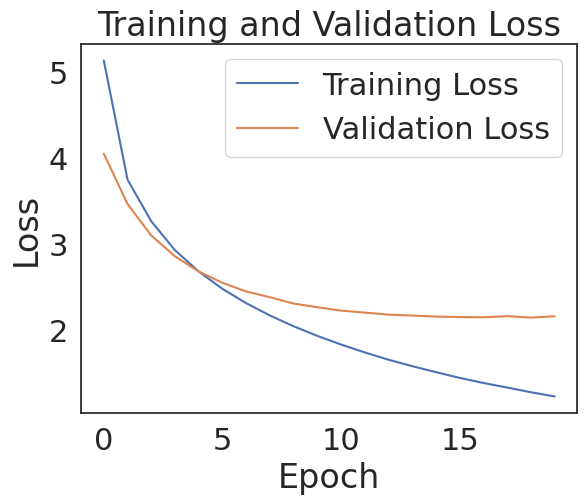

In [20]:
# Plot the loss
plt.figure()
plt.plot(train_losses, label="Training Loss")
plt.plot(val_losses, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.show()

In [21]:
# Define a decode function to generate output sequence using greedy algorithm
# This basically saves us some compute time by taking a bunch of shortcuts (e.g. not computing the full softmax)
def greedy_decode(model, src, max_len, start_symbol):
    model.eval()

    src = src.to(device)

    # Encode the source sentence
    src_emb = model.positional_encoding(model.src_tok_emb(src))
    memory = model.transformer.encoder(src_emb)

    # Start target sequence with <bos>
    ys = torch.ones(1, 1).fill_(start_symbol).type(torch.long).to(device)

    for i in range(max_len - 1):
        tgt_mask = generate_square_subsequent_mask(ys.size(0)).to(device)

        tgt_emb = model.positional_encoding(model.tgt_tok_emb(ys))
        out = model.transformer.decoder(tgt_emb, memory, tgt_mask=tgt_mask)

        # Convert decoder output to vocabulary scores
        prob = model.generator(out[-1, :])

        # Pick the most likely next token
        next_word = torch.argmax(prob, dim=1).item()

        # Add predicted token to output sequence
        ys = torch.cat(
            [ys, torch.ones(1, 1).type_as(src.data).fill_(next_word)],
            dim=0
        )

        # Stop if model predicts <eos>
        if next_word == EOS_IDX:
            break

    return ys

# Define a translation function that actually uses the model to translate a sentence from source to target
def translate(model, src_sentence):
    model.eval()

    # Convert source sentence into tensor indices
    src = text_transform[SRC_LANGUAGE](src_sentence).reshape(-1, 1)

    # Generate predicted output token indices
    tgt_tokens = greedy_decode(
        model,
        src,
        max_len=src.shape[0] + 10,
        start_symbol=BOS_IDX
    ).flatten()

    # Convert indices back into words
    translated_tokens = vocab_transform[TGT_LANGUAGE].lookup_tokens(list(tgt_tokens.cpu().numpy()))

    # Remove special tokens
    translated_tokens = [
        token for token in translated_tokens
        if token not in ["<bos>", "<eos>", "<pad>"]
    ]

    return " ".join(translated_tokens)

## Let's try the model out on a few of our test sequences. Print the first 10 target/translated sequences from our test set

In [22]:
for i in range(10):
    german_sentence, english_sentence = test_data[i]

    predicted_translation = translate(model, german_sentence)

    print("German input:", german_sentence)
    print("Target English:", english_sentence)
    print("Model translation:", predicted_translation)
    print()

German input: Eine Frau mit rotem Kopftuch geht durch einen Zugangsweg auf eine Straße.
Target English: A woman in a red scarf walking through an entryway on a street.
Model translation: A woman in a red headscarf walks through a street .

German input: Eine Gruppe indischer Jungen macht das Peace-Zeichen.
Target English: A group of Indian boys giving the peace sign.
Model translation: A group of Indian boys doing the peace sign .

German input: Ein kleiner Junge springt von einem Dock in einen See.
Target English: A little boy jumping off of a dock into a lake.
Model translation: A little boy jumping off a dock into a lake .

German input: Ein Mann in Grün springt auf seinem Motorrad über mehrere andere Motorräder.
Target English: A man in green jumps serveral motorbikes on his own motorbike.
Model translation: A man in green jumps over his motorcycle over several others .

German input: Eine Gruppe aus drei Männern und zwei Frauen sitzt an einem Tisch mit Essen, Getränken und einem S